<a href="https://colab.research.google.com/github/hmmnyamminji/python/blob/main/Outlier%EC%9D%B4%EC%83%81%EC%B9%98%EC%B2%98%EB%A6%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### 환경설정

In [3]:
# 구글 드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')

# 드라이브에 저장된 폰트 등록
import matplotlib as mpl
import matplotlib.pyplot as plt # 그래프를 그리는 pyplot 모듈
import matplotlib.font_manager as fm # 폰트 관리 모듈

# 드라이브 내 폰트 경로
font_path = '/content/drive/MyDrive/kwu/Bigdata/dataPreProcessing/NanumGothic.ttf'

fm.fontManager.addfont(font_path)
mpl.rc('font',family='NanumGothic') #matplotlib 기본 폰트로 설정
plt.rcParams['axes.unicode_minus'] = False # 마이너스(-) 기호가 깨지지 않도록 비활성화

print("현재 폰트: ", plt.rcParams['font.family'])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
현재 폰트:  ['NanumGothic']


In [4]:
import pandas as pd # 데이터프레임 조작
import numpy as np # 수치 계산 및 NaN 처리
import matplotlib.pyplot as plt # 그래프 시각화
import seaborn as sns # 통계 시각화

# 타이타닉 데이터 로드
titanic = pd.read_csv('/content/drive/MyDrive/kwu/Bigdata/dataPreProcessing/train.csv')
print(titanic.shape)
display(titanic.head())
titanic.head()


(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 타이타닉 결측치 전처리

In [12]:
titanic_clean = titanic.copy()

#Cabin 열 삭제
titanic_clean = titanic_clean.drop(columns=['Cabin'])

# Age 결측치 처리
titanic_clean['Age'] = titanic_clean.groupby(['Sex','Pclass'])['Age'].transform(lambda x: x.fillna(x.median()))

# Embarked 결측치 처리
titanic_clean['Embarked'] = titanic_clean['Embarked'].fillna(titanic_clean['Embarked'].mode()[0])

# Embarked 결측치 처리
titanic_clean['Embarked'] = titanic_clean['Embarked'].fillna(titanic_clean['Embarked'].mode()[0])

# 최종 결측치 현황 확인
print("전처리 후 결측치: ")
print(titanic_clean.isnull().sum()[titanic_clean.isnull().sum()>0])

print(f"₩n 원본 shape: {titanic.shape}")
print(f"전처리 후 shape: {titanic_clean.shape}")


전처리 후 결측치: 
Series([], dtype: int64)
₩n 원본 shape: (891, 12)
전처리 후 shape: (891, 11)


### 타이타닉 이상치 탐색 시각화

In [13]:
from scipy import stats # 통계 연산 모듈, Z-score 계산, Q-Q plot 등에 사용

print(titanic_clean[['Age', 'Fare',]].describe()) # 기술 통계량 출력
# 이상치가 있으면: 평균 >> 중앙값(50%), 최대값이 75%보다 극단적으로 큰 경우

              Age        Fare
count  891.000000  891.000000
mean    29.112424   32.204208
std     13.304424   49.693429
min      0.420000    0.000000
25%     21.500000    7.910400
50%     26.000000   14.454200
75%     36.000000   31.000000
max     80.000000  512.329200


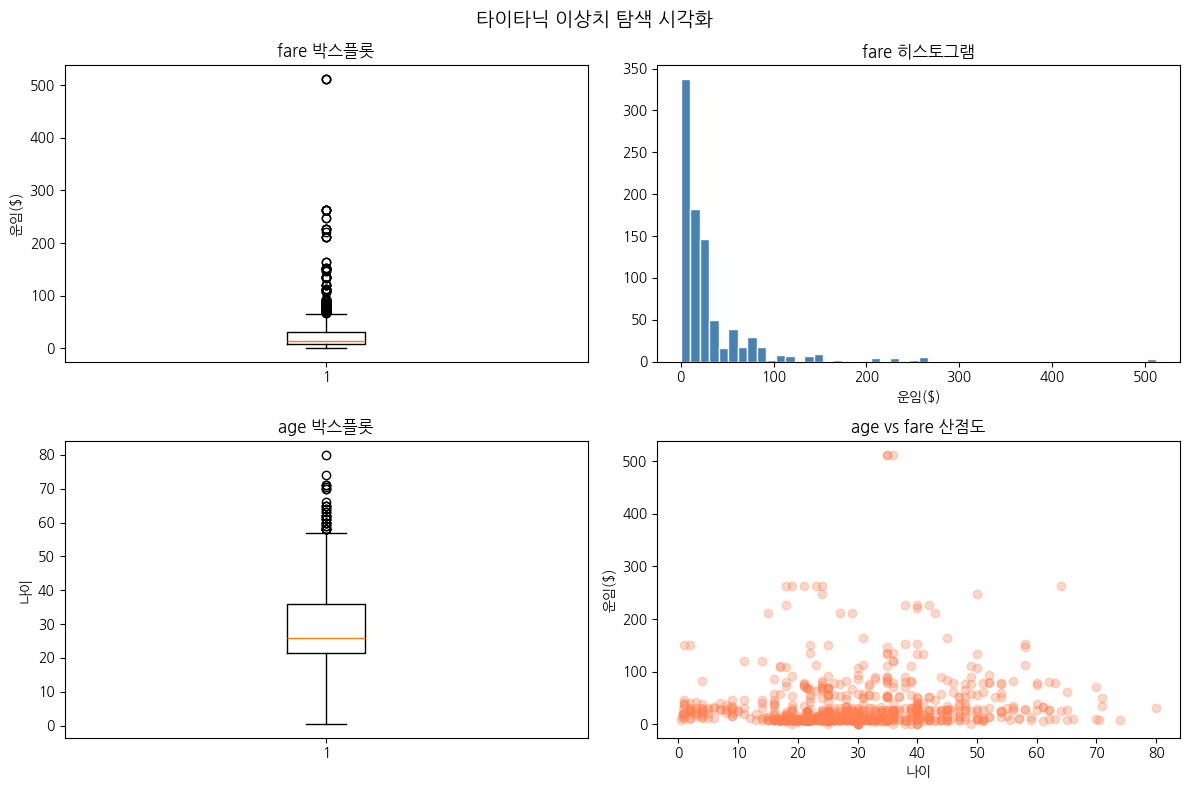

운임 상위 10개
258    512.3292
679    512.3292
737    512.3292
27     263.0000
88     263.0000
341    263.0000
438    263.0000
311    262.3750
742    262.3750
118    247.5208
Name: Fare, dtype: float64


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('타이타닉 이상치 탐색 시각화', fontsize=14)

# fare 박스플롯
axes[0, 0].boxplot(titanic['Fare'].dropna())
axes[0, 0].set_title('fare 박스플롯')
axes[0, 0].set_ylabel('운임($)')

# fare 히스토그램
axes[0, 1].hist(titanic_clean['Fare'], bins=50, color='steelblue', edgecolor='white')
axes[0, 1].set_title('fare 히스토그램')
axes[0, 1].set_xlabel('운임($)')

# age 박스플롯
axes[1, 0].boxplot(titanic_clean['Age'].dropna())
axes[1, 0].set_title('age 박스플롯')
axes[1, 0].set_ylabel('나이')

# 산점도
axes[1, 1].scatter(titanic_clean['Age'], titanic_clean['Fare'], alpha=0.3, color='coral')
axes[1, 1].set_title('age vs fare 산점도')
axes[1, 1].set_xlabel('나이')
axes[1, 1].set_ylabel('운임($)')

plt.tight_layout()
plt.show()

print('운임 상위 10개')
print(titanic_clean['Fare'].nlargest(10))


### 실습2 2.IQR 방법으로 이상치 탐지

In [21]:
# IQR(사분위 범위) 계산
Q1 = titanic_clean['Fare'].quantile(0.25)
Q3 = titanic_clean['Fare'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR # 이상치 하한
upper_bound = Q3 + 1.5 * IQR # 이상치 상한

print(f"Q1: {Q1: .1f}")
print(f"Q3: {Q3: .1f}")
print(f"IQR: {IQR: .1f}")
print(f"정상 범위: {lower_bound: .1f} ~ {upper_bound: .1f}")

# 이상치 마스킹
outlier_mask = (titanic_clean['Fare'] < lower_bound) | (titanic_clean['Fare'] > upper_bound)
outliers = titanic_clean[outlier_mask] # 이상치 마스크가 True인 행만 추출

print("₩n 이상치 승객 상위 5명")
print(outliers[['Pclass','Sex','Age','Fare','Survived']].head())

print(f"₩n 이상치 개수: {outlier_mask.sum()}")
print(f"전체 대비 비율: {outlier_mask.mean()*100: .1f}%")

Q1:  7.9
Q3:  31.0
IQR:  23.1
정상 범위: -26.7 ~  65.6
₩n 이상치 승객 상위 5명
    Pclass     Sex   Age      Fare  Survived
1        1  female  38.0   71.2833         1
27       1    male  19.0  263.0000         0
31       1  female  35.0  146.5208         1
34       1    male  28.0   82.1708         0
52       1  female  49.0   76.7292         1
₩n 이상치 개수: 116
전체 대비 비율:  13.0%


### 실습 3. Z-score 방법으로 이상치 탐지

In [22]:
from scipy import stats
import pandas as pd

# Z-score 계산
fare_zscore = stats.zscore(titanic_clean['Fare'].dropna())  # NaN 제거 후 Z-score 계산

# Z-score를 Series로 변환 (원래 index 유지)
zscore_series = pd.Series(fare_zscore, index=titanic_clean['Fare'].dropna().index)

# |Z| > 3 이상치를 True로 표시
outlier_z_mask = zscore_series.abs() > 3

print(f"Z-score 기준 이상치 수: {outlier_z_mask.sum()}")

# ---------------------------
# IQR vs Z-score 비교
# ---------------------------

fare_clean = titanic_clean[['Fare']].copy()   # 새 DataFrame 생성

# Z-score 이상치 여부 추가
fare_clean['Z_outlier'] = False
fare_clean.loc[outlier_z_mask.index, 'Z_outlier'] = outlier_z_mask

# IQR 계산
Q1 = fare_clean['Fare'].quantile(0.25)
Q3 = fare_clean['Fare'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# IQR 이상치 여부
fare_clean['IQR_outlier'] = (fare_clean['Fare'] < lower_bound) | (fare_clean['Fare'] > upper_bound)

# 결과 확인
print("IQR 기준 이상치 수:", fare_clean['IQR_outlier'].sum())

# 두 방법 비교
comparison = fare_clean[['Fare','Z_outlier','IQR_outlier']]
print(comparison.head())


Z-score 기준 이상치 수: 20
IQR 기준 이상치 수: 116
      Fare  Z_outlier  IQR_outlier
0   7.2500      False        False
1  71.2833      False         True
2   7.9250      False        False
3  53.1000      False        False
4   8.0500      False        False


### 실습 4. 이상치 시각화 - 탐지 결과 표시

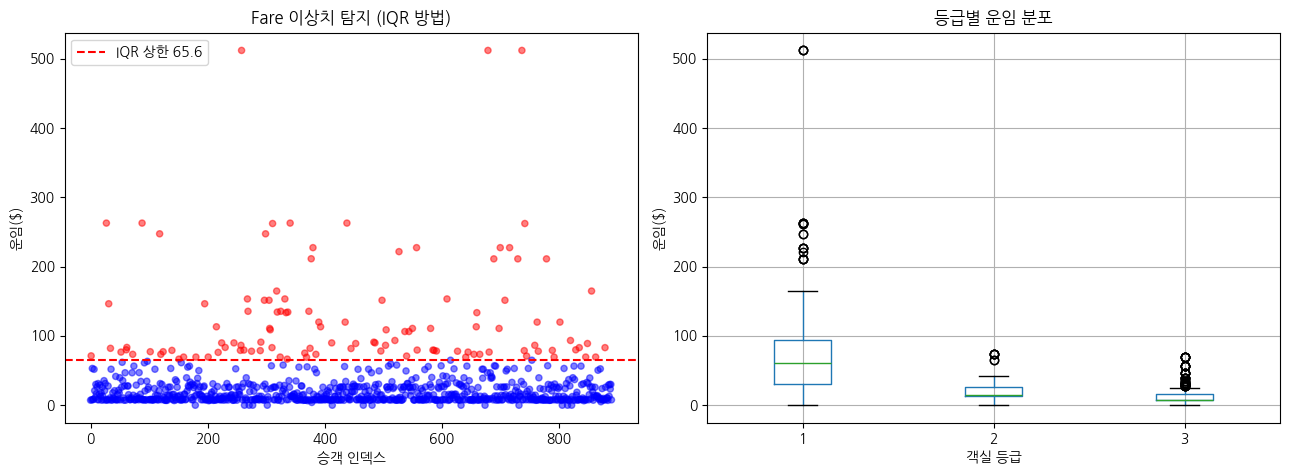

In [29]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))  # 1x2 서브플롯 생성

# 공통 색상 설정: IQR 상한 초과만 빨강
colors = titanic_clean['Fare'].apply(
    lambda x: 'red' if x > upper_bound else 'blue'
)

# -------------------------
# 1️⃣ 이상치 강조 산점도
# -------------------------
axes[0].scatter(
    range(len(titanic_clean)),
    titanic_clean['Fare'],
    c=colors,
    alpha=0.5,
    s=20
)

# IQR 상한선
axes[0].axhline(
    y=upper_bound,
    color='red',
    linestyle='--',
    label=f'IQR 상한 {upper_bound:.1f}'
)

axes[0].set_title('Fare 이상치 탐지 (IQR 방법)')
axes[0].set_xlabel('승객 인덱스')
axes[0].set_ylabel('운임($)')
axes[0].legend()

# -------------------------
# 2️⃣ 등급별 박스플롯
# -------------------------
titanic_clean.boxplot(
    column='Fare',
    by='Pclass',
    ax=axes[1]
)

axes[1].set_title('등급별 운임 분포')
axes[1].set_xlabel('객실 등급')
axes[1].set_ylabel('운임($)')

plt.suptitle('')   # pandas boxplot 기본 제목 제거
plt.tight_layout()
plt.show()


### 실습 5. 이상치 처리 - 제거(Drop)

In [33]:
# 이상치 제거
titanic_no_outlier = titanic[~outlier_mask].copy() # ~outlier_mask: 이상치 마스크를 반전(NOT 연산), 정상치

print(f"원본 행 수: {len(titanic_clean)}")
print(f"이상치 제거 후: {len(titanic_no_outlier)}") # 정상 데이터만

# 제거 전후 fare 통계 전후
comparison = pd.DataFrame({
    '원본': titanic_clean['Fare'].describe(),
    '이상치 제거': titanic_no_outlier['Fare'].describe()
}).round(2)
display(comparison)

원본 행 수: 891
이상치 제거 후: 775


,원본,이상치 제거
count,891.00,775.00
mean,32.20,17.82
std,49.69,13.58
min,0.00,0.00
25%,7.91,7.90
50%,14.45,13.00
75%,31.00,26.00
max,512.33,65.00


### 실습 6. 이상치 처리 - 캡핑(Clipping)

캠핑 전 최대값: 512.3292
캠핑 후 최대값: 65.6344
행 수 변화 없음: 891


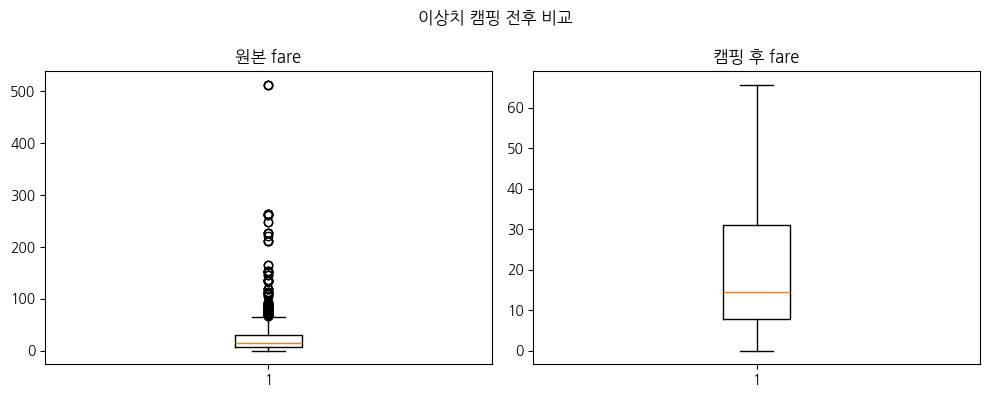

In [39]:
 # 이상치를 제거하지 않고 경계값으로 대체, 데이터 수(891행) 유지
titanic_clipped = titanic_clean.copy()
titanic_clipped['Fare_clipped'] = titanic_clipped['Fare'].clip(
    lower = max(lower_bound, 0), #lower_bound(-26.7)와 0 중 큰 값 선택
    upper = upper_bound
 ) # clip(): 범위 밖의 값을 경계값으로 강제 변환

# 결과 확인
print('캠핑 전 최대값:', titanic_clean['Fare'].max())
print('캠핑 후 최대값:', titanic_clipped['Fare_clipped'].max())
print('행 수 변화 없음:', len(titanic_clipped))

# 전후 비교 박스플롯
fig, axes = plt.subplots(1,2, figsize=(10,4))
axes[0].boxplot(titanic_clean['Fare'])
axes[0].set_title('원본 fare')
axes[1].boxplot(titanic_clipped['Fare_clipped'])
axes[1].set_title('캠핑 후 fare')

plt.suptitle('이상치 캠핑 전후 비교')
plt.tight_layout()
plt.show()

### 정규분포 확인 방법

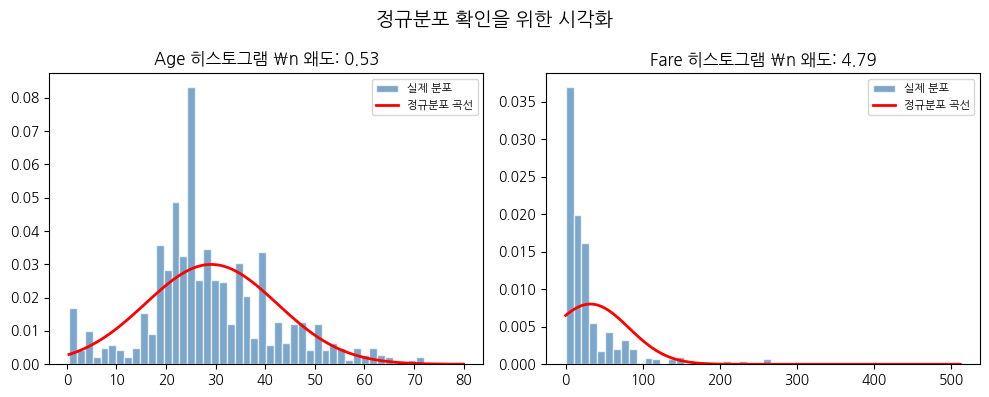

In [42]:
# 정규분포 확인을 위한 시각화
fig, axes = plt.subplots(1,2, figsize=(10,4))
fig.suptitle('정규분포 확인을 위한 시각화', fontsize=14)

cols = ['Age', 'Fare']

for i, col in enumerate(cols):
  data = titanic_clean[col].dropna()
  # 히스토그램 + 정규분포 곡선
  ax1 = axes[i]
  ax1.hist(data, bins=50, density=True, color='steelblue', edgecolor='white', alpha=0.7, label='실제 분포')
  # 정규분포 곡선 그리기
  x = np.linspace(data.min(), data.max(), 100)
                              # 데이터 최소~최대 범위에서 100개 균등 간격 x값 생성
  ax1.plot(x, stats.norm.pdf(x, data.mean(), data.std()),color='red',linewidth=2, label='정규분포 곡선')
  ax1.set_title(f'{col} 히스토그램 ₩n 왜도: {data.skew():.2f}')
                              # 왜도가 -1~1 사이인 정규분포에 가까움
  ax1.legend(fontsize=8)

plt.tight_layout()
plt.show()


### 실습 7. 이상치 처리 - 로그 변환
* np.log1p()는 log(1+x)를 계산해 주는 넘파이(NumPy) 함수
* "데이터가 한쪽으로 크게 치우쳐 있을 때(양의 왜도)" 이를 정규분포 형태로 변환하기 위해 사용
* 모든 데이터에 1을 더한 뒤 로그를 취하면, 0이었던 데이터는 log(1)=0이 되어 안전하게 변환
*1p는 plus 1을 의미
* 값이 너무 큰 데이터(이상치)의 수치를 압축

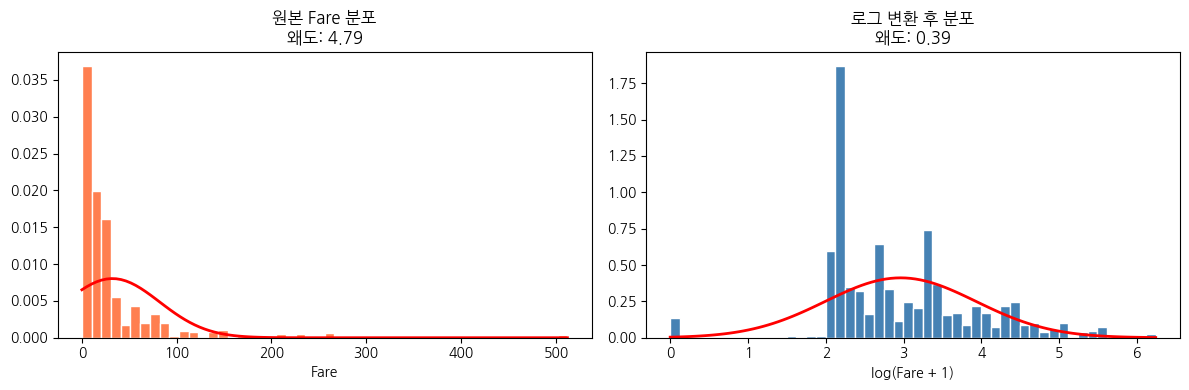

원본 Fare 왜도: 4.79
로그 변환 후 왜도: 0.39


In [52]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 로그 변환
titanic_log = titanic_clean.copy()
titanic_log['Fare_log'] = np.log1p(titanic_clean['Fare'])

fig, axes = plt.subplots(1,2, figsize=(12,4))

# -------------------------
# 1️⃣ 원본 Fare 분포
# -------------------------
data1 = titanic_clean['Fare'].dropna()

axes[0].hist(data1, bins=50, density=True, color='coral', edgecolor='white')

x = np.linspace(data1.min(), data1.max(), 100)

axes[0].plot(
    x,
    stats.norm.pdf(x, data1.mean(), data1.std()),
    color='red',
    linewidth=2
)

axes[0].set_title(f'원본 Fare 분포\n왜도: {data1.skew():.2f}')
axes[0].set_xlabel('Fare')


# -------------------------
# 2️⃣ 로그 변환 후
# -------------------------
data2 = titanic_log['Fare_log'].dropna()

axes[1].hist(data2, bins=50, density=True, color='steelblue', edgecolor='white')

x = np.linspace(data2.min(), data2.max(), 100)

axes[1].plot(
    x,
    stats.norm.pdf(x, data2.mean(), data2.std()),
    color='red',
    linewidth=2
)

axes[1].set_title(f'로그 변환 후 분포\n왜도: {data2.skew():.2f}')
axes[1].set_xlabel('log(Fare + 1)')

plt.tight_layout()
plt.show()


# 왜도 비교
print(f"원본 Fare 왜도: {data1.skew():.2f}")
print(f"로그 변환 후 왜도: {data2.skew():.2f}")


### 실습 8. 다변수 이상치 탐지 (나이+운임)

다변수 이상치: 5개
       Age      Fare     Age_z    Fare_z
195  58.00  146.5208  2.172495  2.301729
268  58.00  153.4625  2.172495  2.441498
297   2.00  151.5500 -2.038995  2.402990
305   0.92  151.5500 -2.120216  2.402990
438  64.00  263.0000  2.623727  4.647001


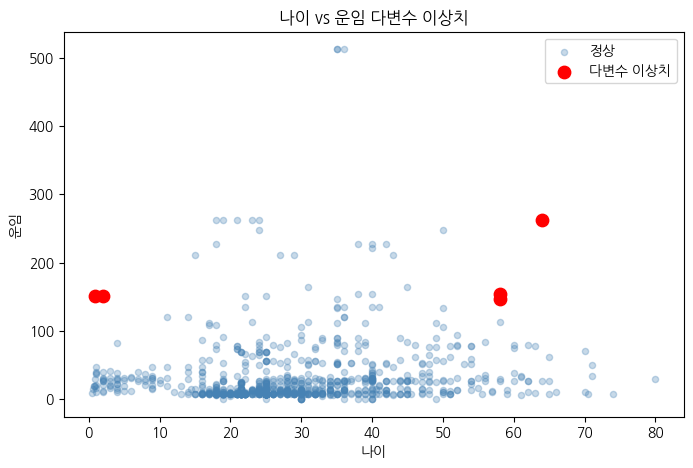

In [57]:
# 다변수 이상치 탐지: 단일 변수로는 정상이지만 조항이 이상한 경우
# 예: 나이 1살인데 운임 500달러 -> Age 단독 OK, Fare 단독 OK, 하지만 조합이 이상함

titanic_bivar = titanic_clean[['Age','Fare']].dropna().copy()

# 두 변수에 각각 Z-score 적용
titanic_bivar['Age_z'] = stats.zscore(titanic_bivar['Age'])
titanic_bivar['Fare_z'] = stats.zscore(titanic_bivar['Fare'])

# 두 변수 모두 |Z| > 2를 다변수 이상치로 판단
both_extreme = (titanic_bivar['Age_z'].abs()>2) & (titanic_bivar['Fare_z'].abs()>2)

print(f"다변수 이상치: {both_extreme.sum()}개")
print(titanic_bivar[both_extreme]) #True에 해당하는 행 출력

# 산점도로 다변수 이상치 시각화
plt.figure(figsize=(8,5))
normal = ~both_extreme
plt.scatter(titanic_bivar.loc[normal, 'Age'],
            titanic_bivar.loc[normal, 'Fare'],
            alpha=0.3, color='steelblue', label='정상', s=20)
plt.scatter(titanic_bivar.loc[both_extreme,'Age'],
            titanic_bivar.loc[both_extreme, 'Fare'],
            color='red', label='다변수 이상치', s=80, zorder=5) #zorder=5 정상 점보다 위에 그려짐

plt.xlabel('나이')
plt.ylabel('운임')
plt.title('나이 vs 운임 다변수 이상치')
plt.legend()
plt.show()

### 실습 9. 종합 - 처리 방법별 결과 비교

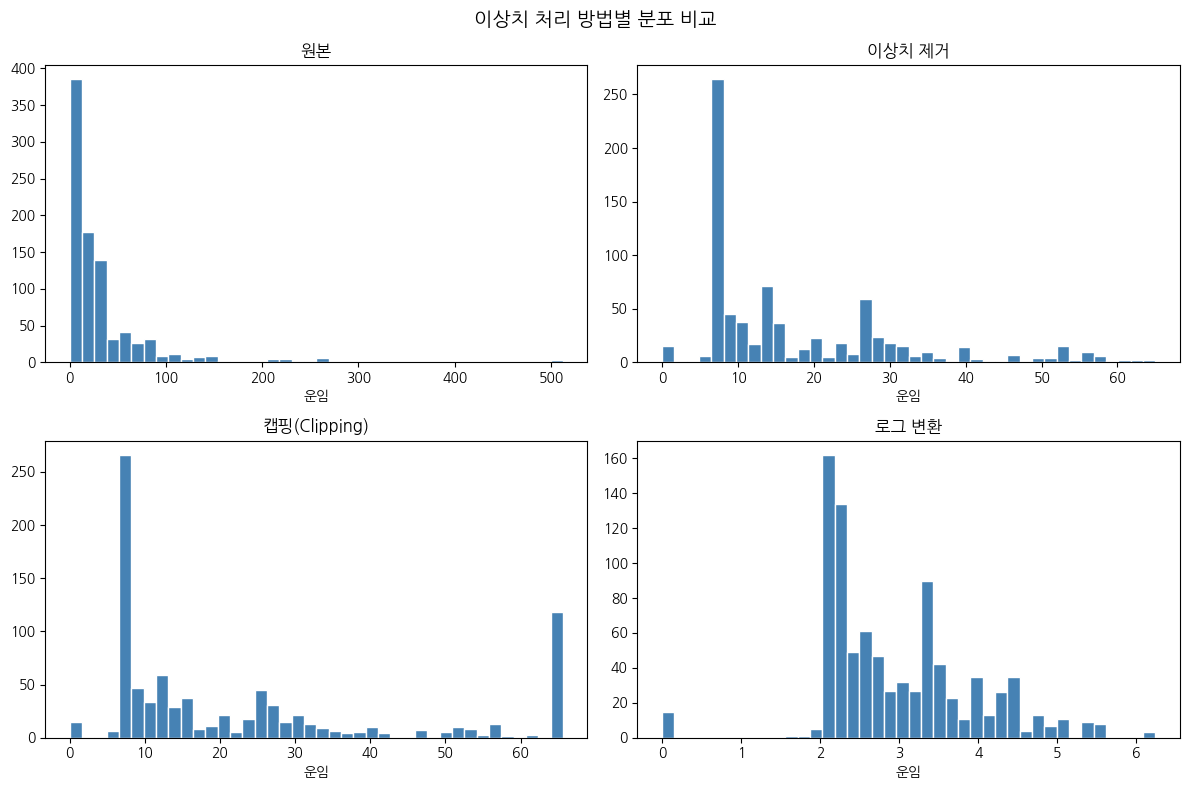

,원본,제거,캠핑,로그 변환
count,891.00,775.00,891.00,891.00
mean,32.20,17.82,24.05,2.96
std,49.69,13.58,20.48,0.97
min,0.00,0.00,0.00,0.00
25%,7.91,7.90,7.91,2.19
50%,14.45,13.00,14.45,2.74
75%,31.00,26.00,31.00,3.47
max,512.33,65.00,65.63,6.24


In [71]:
# 이상치 처리 4가지 방법을 한눈에 비교
fare_original = titanic_clean['Fare']

# 방법 2: 이상치 제거(행 수 줄어듦)
fare_dropped = titanic_clean.loc[~outlier_mask,'Fare'] # 정상 데이터만 선택

# 방법 3: 캠핑 (이상치를 상한값으로 교체, 행 수 유지)
fare_clipped = titanic_clean['Fare'].clip(upper=upper_bound)
                      # 상한을 초가한 값을 상한 값으로 대체

# 방법 4: 로그 변환 (분포 형태 자체를 반환 - 정규 분포와 비슷하게)
fare_log = np.log1p(titanic_clean['Fare'])
                      # log(1+x) 변환으로 오른쪽 꼬리 분포를 정규분포에 가깝게 변환

fig, axes = plt.subplots(2,2, figsize=(12, 8)) # 2행x2열
fig.suptitle('이상치 처리 방법별 분포 비교', fontsize=14)

for ax, data, title in zip(
    axes.flatten(), # 2D 배열을 1D로 펼쳐 순서대로 순회
    [fare_original, fare_dropped, fare_clipped, fare_log],
    ['원본', '이상치 제거', '캡핑(Clipping)','로그 변환']
):

    ax.hist(data, bins=40, edgecolor='white', color='steelblue')
    ax.set_title(title)
    ax.set_xlabel('운임')

plt.tight_layout()
plt.show()

# 방법별 요약 통계 비교표
summary = pd.DataFrame({
    '원본': fare_original.describe(),
    '제거': fare_dropped.describe(),
    '캠핑': fare_clipped.describe(),
    '로그 변환': fare_log.describe()
}).round(2)
display(summary)